In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbHVjYS9Eb2t1bWVudGUvZGV2L2FyYmVpdC9sdWNhaC50ZWNoL3F1b3RlbWUuZ2l0aHViLmlvL3Bvc3RzL2tub3RzLXRvLW5hcm5pYQ=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/importlib/_bootstrap.py": 1746706798.1099684, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/importlib/_bootstrap_external.py": 1746706798.1109684, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/zipimport.py": 1746706798.599966, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/codecs.py": 1746706797.6719706, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/encodings/aliases.py": 1746706797.7389703, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/encodings/__init__.py": 1746706797.7359703, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/encodings/utf_8.py": 1746706797.79997, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/abc.py": 1746706797.6389706, "/home/luca/.local/sh

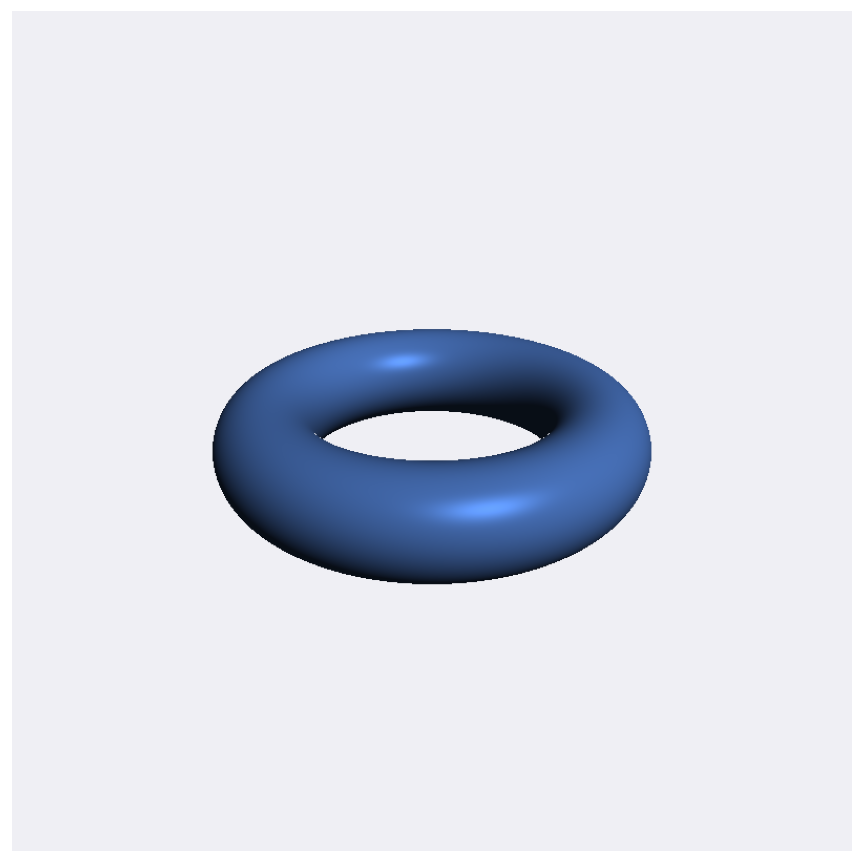

In [2]:
#| label: fig-torus
#| fig-cap: The unknot — a simple torus in ℝ³.
import numpy as np
import numba as nb
from numba import njit, prange
import matplotlib.pyplot as plt

# ── Signed Distance Functions ────────────────────────────────────────

@njit
def sdf_torus(p, R, r):
    """SDF for a torus centred at the origin lying in the xz-plane.
    R = major radius, r = minor radius."""
    q = np.sqrt(p[0]**2 + p[2]**2) - R
    return np.sqrt(q**2 + p[1]**2) - r

# ── Ray stepping (swappable for non-Euclidean geometries) ────────────

@njit
def step_ray_euclidean(pos, direction, dt):
    """Advance a ray in flat R^3: straight-line geodesic."""
    new_pos = np.empty(3)
    new_dir = np.empty(3)
    for i in range(3):
        new_pos[i] = pos[i] + dt * direction[i]
        new_dir[i] = direction[i]          # direction unchanged in flat space
    return new_pos, new_dir

# ── Surface normal via central differences ───────────────────────────

@njit
def estimate_normal_torus(p, R, r):
    eps = 1e-4
    n = np.empty(3)
    for i in range(3):
        p_plus  = p.copy(); p_plus[i]  += eps
        p_minus = p.copy(); p_minus[i] -= eps
        n[i] = sdf_torus(p_plus, R, r) - sdf_torus(p_minus, R, r)
    length = np.sqrt(n[0]**2 + n[1]**2 + n[2]**2)
    if length > 0:
        for i in range(3):
            n[i] /= length
    return n

# ── Phong lighting ───────────────────────────────────────────────────

@njit
def shade(hit_pos, normal, ray_dir, light_dir):
    """Simple Phong shading (ambient + diffuse + specular)."""
    # normalise light direction
    ll = np.sqrt(light_dir[0]**2 + light_dir[1]**2 + light_dir[2]**2)
    L = np.empty(3)
    for i in range(3):
        L[i] = light_dir[i] / ll

    # diffuse
    diff = 0.0
    for i in range(3):
        diff += normal[i] * L[i]
    diff = max(diff, 0.0)

    # specular (Blinn-Phong)
    H = np.empty(3)
    for i in range(3):
        H[i] = L[i] - ray_dir[i]
    hl = np.sqrt(H[0]**2 + H[1]**2 + H[2]**2)
    if hl > 0:
        for i in range(3):
            H[i] /= hl
    spec = 0.0
    for i in range(3):
        spec += normal[i] * H[i]
    spec = max(spec, 0.0) ** 64

    ambient  = 0.10
    diffuse  = 0.70 * diff
    specular = 0.40 * spec
    return ambient + diffuse + specular

# ── Main ray-march renderer ─────────────────────────────────────────

@njit(parallel=True)
def render(width, height, fov, cam_pos, cam_target,
           torus_R, torus_r, light_dir,
           max_steps, max_dist, hit_eps):
    """Ray-march a torus scene.  Returns an (H, W, 3) float64 image."""
    image = np.zeros((height, width, 3))

    aspect = width / height
    half_w = np.tan(fov / 2.0)

    # camera basis
    forward = np.empty(3)
    for i in range(3):
        forward[i] = cam_target[i] - cam_pos[i]
    fl = np.sqrt(forward[0]**2 + forward[1]**2 + forward[2]**2)
    for i in range(3):
        forward[i] /= fl

    world_up = np.array([0.0, 1.0, 0.0])
    right = np.empty(3)
    right[0] = forward[1]*world_up[2] - forward[2]*world_up[1]
    right[1] = forward[2]*world_up[0] - forward[0]*world_up[2]
    right[2] = forward[0]*world_up[1] - forward[1]*world_up[0]
    rl = np.sqrt(right[0]**2 + right[1]**2 + right[2]**2)
    for i in range(3):
        right[i] /= rl

    up = np.empty(3)
    up[0] = right[1]*forward[2] - right[2]*forward[1]
    up[1] = right[2]*forward[0] - right[0]*forward[2]
    up[2] = right[0]*forward[1] - right[1]*forward[0]

    # object colour (torus)
    obj_col = np.array([0.35, 0.55, 0.90])
    # background colour
    bg_col  = np.array([0.94, 0.94, 0.96])

    for py in prange(height):
        for px in range(width):
            # NDC → camera ray direction
            u = (2.0 * (px + 0.5) / width  - 1.0) * half_w * aspect
            v = (2.0 * (py + 0.5) / height - 1.0) * half_w
            d = np.empty(3)
            for i in range(3):
                d[i] = forward[i] + u * right[i] - v * up[i]
            dl = np.sqrt(d[0]**2 + d[1]**2 + d[2]**2)
            for i in range(3):
                d[i] /= dl

            # march
            pos = cam_pos.copy()
            direction = d.copy()
            hit = False
            for _ in range(max_steps):
                dist = sdf_torus(pos, torus_R, torus_r)
                if dist < hit_eps:
                    hit = True
                    break
                if dist > max_dist:
                    break
                # *** THIS is the line we swap for non-Euclidean geometry ***
                pos, direction = step_ray_euclidean(pos, direction, dist)

            if hit:
                normal = estimate_normal_torus(pos, torus_R, torus_r)
                brightness = shade(pos, normal, d, light_dir)
                for c in range(3):
                    val = obj_col[c] * brightness
                    image[py, px, c] = min(max(val, 0.0), 1.0)
            else:
                for c in range(3):
                    image[py, px, c] = bg_col[c]

    return image


# ── SDF: rotated torus (hole along x-axis) ──────────────────────────

@njit
def sdf_torus_rotated(p, center_x, R, r):
    """SDF for a torus centred at (center_x, 0, 0) with hole along the x-axis."""
    px = p[0] - center_x
    q = np.sqrt(p[1]**2 + p[2]**2) - R
    return np.sqrt(q**2 + px**2) - r

# ── Portal crossing detection ────────────────────────────────────────

@njit
def check_portal_crossing(pos_old, pos_new, portal_x, portal_R):
    """Check if a ray step crossed the portal disk at x = portal_x
    with radius portal_R (in the yz-plane).
    Returns True if the ray crossed from one side to the other
    AND the crossing point is inside the disk."""
    x0 = pos_old[0] - portal_x
    x1 = pos_new[0] - portal_x
    if x0 * x1 >= 0.0:
        return False
    t = x0 / (x0 - x1)
    cy = pos_old[1] + t * (pos_new[1] - pos_old[1])
    cz = pos_old[2] + t * (pos_new[2] - pos_old[2])
    return (cy * cy + cz * cz) < portal_R * portal_R

# ── Helper: display a rendered image (no text, figure caption via Quarto) ──

def show_render(img):
    """Display a rendered image with no axes, titles, or labels.
    The figure is sized so it looks good on the page without being
    too large or too small."""
    fig, ax = plt.subplots(figsize=(7, 7), dpi=120)
    ax.imshow(img)
    ax.set_axis_off()
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.show()


# ── Scene parameters ─────────────────────────────────────────────────

W, H     = 800, 800
fov      = np.pi / 3.0           # 60°
cam_pos  = np.array([0.0, 2.0, 4.0])
cam_tgt  = np.array([0.0, 0.0, 0.0])
light    = np.array([2.0, 4.0, 3.0])
torus_R  = 1.0                   # major radius  (unknot!)
torus_r  = 0.3                   # minor radius

img = render(W, H, fov, cam_pos, cam_tgt,
             torus_R, torus_r, light,
             max_steps=256, max_dist=50.0, hit_eps=1e-4)

show_render(img)

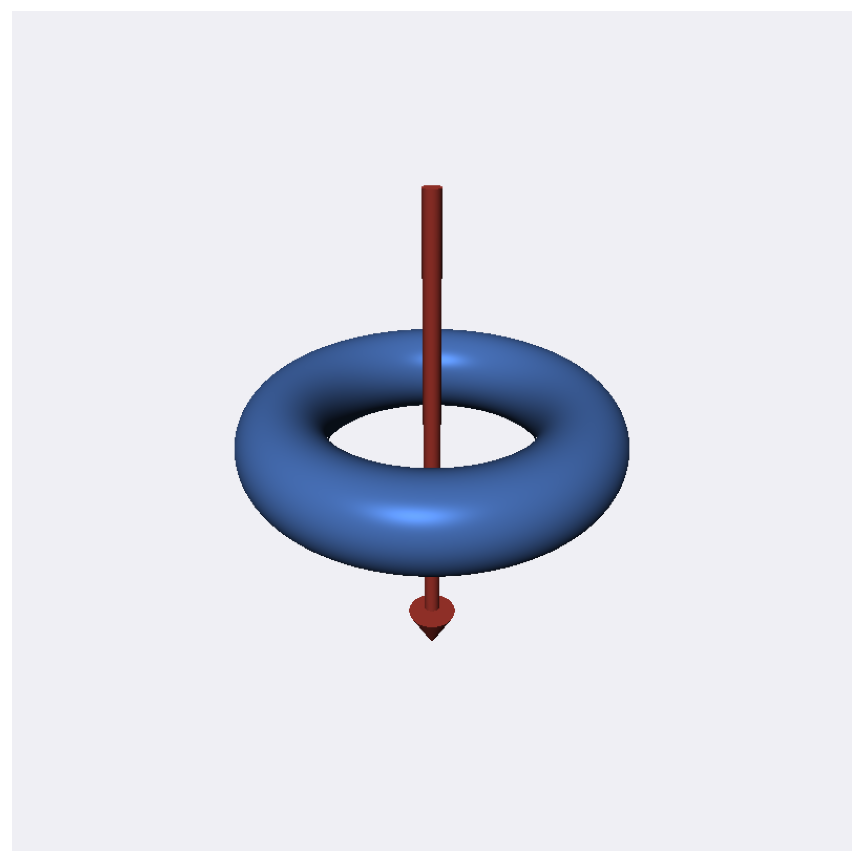

In [3]:
#| label: fig-torus-arrow
#| fig-cap: A torus (the unknot) with an arrow passing through it — the gateway between two worlds.

@njit
def sdf_cylinder(p, radius, half_height):
    """SDF for an infinite-height cylinder along the y-axis,
    capped at -half_height and +half_height."""
    d_radial = np.sqrt(p[0]**2 + p[2]**2) - radius
    d_vertical = abs(p[1]) - half_height
    # outside distance
    outside = np.sqrt(max(d_radial, 0.0)**2 + max(d_vertical, 0.0)**2)
    # inside distance
    inside = min(max(d_radial, d_vertical), 0.0)
    return outside + inside

@njit
def sdf_cone(p, radius, height, tip_y):
    """SDF for a cone with apex at (0, tip_y, 0) opening downward,
    base radius `radius` and vertical extent `height`."""
    # translate so tip is at origin
    py = tip_y - p[1]
    if py < 0.0:
        # above the tip
        return np.sqrt(p[0]**2 + p[2]**2 + (p[1] - tip_y)**2)
    pr = np.sqrt(p[0]**2 + p[2]**2)
    # cone surface: r/py = radius/height
    slope = radius / height
    # distance along the cone
    q_x = pr - slope * py
    q_y = py - height
    if q_x <= 0.0 and q_y <= 0.0:
        # inside the cone
        # distance to surface
        cos_a = height / np.sqrt(height**2 + radius**2)
        return -min(-q_x * cos_a, -q_y)
    if q_y > 0.0 and q_x <= 0.0:
        return q_y
    if q_x > 0.0 and q_y <= 0.0:
        cos_a = height / np.sqrt(height**2 + radius**2)
        return q_x * cos_a
    return np.sqrt(q_x**2 + q_y**2)

@njit
def sdf_arrow(p, shaft_radius, shaft_half_h, cone_radius, cone_height, cone_tip_y):
    """SDF for an arrow = cylinder shaft ∪ cone tip (pointing UP)."""
    d_shaft = sdf_cylinder(p, shaft_radius, shaft_half_h)
    d_cone  = sdf_cone(p, cone_radius, cone_height, cone_tip_y)
    return min(d_shaft, d_cone)

@njit
def sdf_arrow_down(p, shaft_radius, shaft_half_h, cone_radius, cone_height, cone_tip_y):
    """SDF for a downward-pointing arrow: flip y so the cone tip is at the bottom."""
    d_shaft = sdf_cylinder(p, shaft_radius, shaft_half_h)
    p_flip = np.empty(3)
    p_flip[0] = p[0]
    p_flip[1] = -p[1]
    p_flip[2] = p[2]
    d_cone = sdf_cone(p_flip, cone_radius, cone_height, cone_tip_y)
    return min(d_shaft, d_cone)

@njit
def estimate_normal_scene(p, torus_R, torus_r,
                          shaft_r, shaft_hh, cone_r, cone_h, cone_ty):
    eps = 1e-4
    n = np.empty(3)
    for i in range(3):
        pp = p.copy(); pp[i] += eps
        pm = p.copy(); pm[i] -= eps
        dp = min(sdf_torus(pp, torus_R, torus_r),
                 sdf_arrow_down(pp, shaft_r, shaft_hh, cone_r, cone_h, cone_ty))
        dm = min(sdf_torus(pm, torus_R, torus_r),
                 sdf_arrow_down(pm, shaft_r, shaft_hh, cone_r, cone_h, cone_ty))
        n[i] = dp - dm
    length = np.sqrt(n[0]**2 + n[1]**2 + n[2]**2)
    if length > 0:
        for i in range(3):
            n[i] /= length
    return n

@njit(parallel=True)
def render_arrow_scene(width, height, fov, cam_pos, cam_target,
                      torus_R, torus_r,
                      shaft_r, shaft_hh, cone_r, cone_h, cone_ty,
                      light_dir, max_steps, max_dist, hit_eps):
    image = np.zeros((height, width, 3))
    aspect = width / height
    half_w = np.tan(fov / 2.0)

    forward = np.empty(3)
    for i in range(3):
        forward[i] = cam_target[i] - cam_pos[i]
    fl = np.sqrt(forward[0]**2 + forward[1]**2 + forward[2]**2)
    for i in range(3):
        forward[i] /= fl

    world_up = np.array([0.0, 1.0, 0.0])
    right = np.empty(3)
    right[0] = forward[1]*world_up[2] - forward[2]*world_up[1]
    right[1] = forward[2]*world_up[0] - forward[0]*world_up[2]
    right[2] = forward[0]*world_up[1] - forward[1]*world_up[0]
    rl = np.sqrt(right[0]**2 + right[1]**2 + right[2]**2)
    for i in range(3):
        right[i] /= rl

    up = np.empty(3)
    up[0] = right[1]*forward[2] - right[2]*forward[1]
    up[1] = right[2]*forward[0] - right[0]*forward[2]
    up[2] = right[0]*forward[1] - right[1]*forward[0]

    torus_col = np.array([0.35, 0.55, 0.90])
    arrow_col = np.array([0.90, 0.30, 0.25])
    bg_col    = np.array([0.94, 0.94, 0.96])

    for py in prange(height):
        for px in range(width):
            u = (2.0 * (px + 0.5) / width  - 1.0) * half_w * aspect
            v = (2.0 * (py + 0.5) / height - 1.0) * half_w
            d = np.empty(3)
            for i in range(3):
                d[i] = forward[i] + u * right[i] - v * up[i]
            dl = np.sqrt(d[0]**2 + d[1]**2 + d[2]**2)
            for i in range(3):
                d[i] /= dl

            pos = cam_pos.copy()
            direction = d.copy()
            hit = False
            for _ in range(max_steps):
                d_torus = sdf_torus(pos, torus_R, torus_r)
                d_arrow = sdf_arrow_down(pos, shaft_r, shaft_hh, cone_r, cone_h, cone_ty)
                dist = min(d_torus, d_arrow)
                if dist < hit_eps:
                    hit = True
                    break
                if dist > max_dist:
                    break
                pos, direction = step_ray_euclidean(pos, direction, dist)

            if hit:
                normal = estimate_normal_scene(pos, torus_R, torus_r,
                                               shaft_r, shaft_hh, cone_r, cone_h, cone_ty)
                brightness = shade(pos, normal, d, light_dir)
                d_torus = sdf_torus(pos, torus_R, torus_r)
                d_arrow = sdf_arrow_down(pos, shaft_r, shaft_hh, cone_r, cone_h, cone_ty)
                col = torus_col if d_torus < d_arrow else arrow_col
                for c in range(3):
                    val = col[c] * brightness
                    image[py, px, c] = min(max(val, 0.0), 1.0)
            else:
                for c in range(3):
                    image[py, px, c] = bg_col[c]

    return image


# ── Render torus + arrow ─────────────────────────────────────────────

img2 = render_arrow_scene(
    800, 800, np.pi / 3.0,
    np.array([3.0, 2.5, 3.0]),       # camera slightly to the side
    np.array([0.0, 0.0, 0.0]),       # look at origin
    1.0, 0.3,                        # torus R, r
    0.06, 1.6,                       # arrow shaft radius, half-height
    0.18, 0.35, 2.0,                 # cone radius, height, tip_y
    np.array([2.0, 4.0, 3.0]),       # light
    256, 50.0, 1e-4
)

show_render(img2)

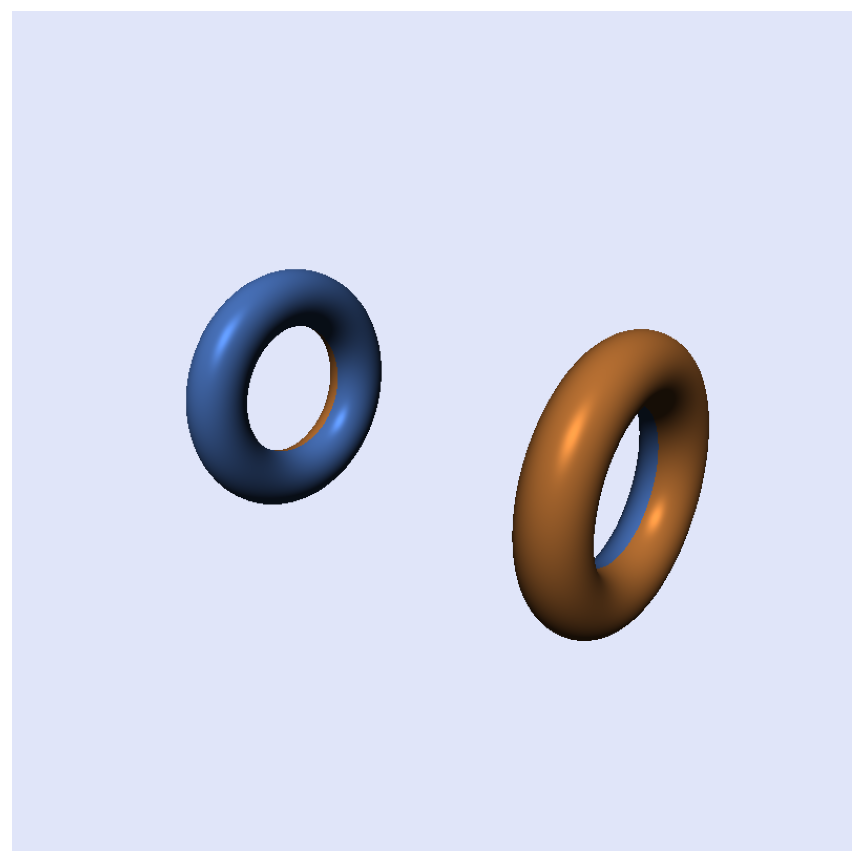

In [4]:
#| label: fig-portal
#| fig-cap: Two tori as portals — light rays passing through one hole are teleported to the other. The blue and orange backgrounds reveal which 'world' each ray ends up in.

@njit
def estimate_normal_two_tori(p, torus_R, torus_r, torus_cx_L, torus_cx_R):
    eps = 1e-4
    n = np.empty(3)
    for i in range(3):
        pp = p.copy(); pp[i] += eps
        pm = p.copy(); pm[i] -= eps
        dp = min(sdf_torus_rotated(pp, torus_cx_L, torus_R, torus_r),
                 sdf_torus_rotated(pp, torus_cx_R, torus_R, torus_r))
        dm = min(sdf_torus_rotated(pm, torus_cx_L, torus_R, torus_r),
                 sdf_torus_rotated(pm, torus_cx_R, torus_R, torus_r))
        n[i] = dp - dm
    length = np.sqrt(n[0]**2 + n[1]**2 + n[2]**2)
    if length > 0:
        for i in range(3):
            n[i] /= length
    return n

@njit(parallel=True)
def render_portal_scene(width, height, fov, cam_pos, cam_target,
                        torus_R, torus_r, torus_cx_L, torus_cx_R,
                        light_dir, max_steps, max_dist, hit_eps):
    """Ray-march with portal teleportation.
    When a ray passes through the disk of one torus, it is teleported
    to the other torus (x shifted by dx = cx_R - cx_L or vice versa)."""
    image = np.zeros((height, width, 3))
    aspect = width / height
    half_w = np.tan(fov / 2.0)
    dx_teleport = torus_cx_R - torus_cx_L

    forward = np.empty(3)
    for i in range(3):
        forward[i] = cam_target[i] - cam_pos[i]
    fl = np.sqrt(forward[0]**2 + forward[1]**2 + forward[2]**2)
    for i in range(3):
        forward[i] /= fl

    world_up = np.array([0.0, 1.0, 0.0])
    right = np.empty(3)
    right[0] = forward[1]*world_up[2] - forward[2]*world_up[1]
    right[1] = forward[2]*world_up[0] - forward[0]*world_up[2]
    right[2] = forward[0]*world_up[1] - forward[1]*world_up[0]
    rl = np.sqrt(right[0]**2 + right[1]**2 + right[2]**2)
    for i in range(3):
        right[i] /= rl

    up = np.empty(3)
    up[0] = right[1]*forward[2] - right[2]*forward[1]
    up[1] = right[2]*forward[0] - right[0]*forward[2]
    up[2] = right[0]*forward[1] - right[1]*forward[0]

    left_torus_col  = np.array([0.35, 0.55, 0.90])
    right_torus_col = np.array([0.90, 0.55, 0.25])
    bg_left         = np.array([0.88, 0.90, 0.98])
    bg_right        = np.array([0.98, 0.91, 0.86])

    for py in prange(height):
        for px in range(width):
            u = (2.0 * (px + 0.5) / width  - 1.0) * half_w * aspect
            v = (2.0 * (py + 0.5) / height - 1.0) * half_w
            d = np.empty(3)
            for i in range(3):
                d[i] = forward[i] + u * right[i] - v * up[i]
            dl = np.sqrt(d[0]**2 + d[1]**2 + d[2]**2)
            for i in range(3):
                d[i] /= dl

            pos = cam_pos.copy()
            direction = d.copy()
            hit = False
            hit_id = -1   # 0 = left torus, 1 = right torus
            n_teleports = 0

            for _ in range(max_steps):
                d_tL = sdf_torus_rotated(pos, torus_cx_L, torus_R, torus_r)
                d_tR = sdf_torus_rotated(pos, torus_cx_R, torus_R, torus_r)
                dist = d_tL
                sid = 0
                if d_tR < dist:
                    dist = d_tR
                    sid = 1

                if dist < hit_eps:
                    hit = True
                    hit_id = sid
                    break
                if dist > max_dist:
                    break

                # step the ray
                old_pos = pos.copy()
                pos, direction = step_ray_euclidean(pos, direction, dist)

                # check portal crossings (max 4 teleports to avoid infinite loops)
                if n_teleports < 4:
                    if check_portal_crossing(old_pos, pos, torus_cx_L, torus_R - torus_r):
                        # crossed left torus disk -> teleport to right torus
                        pos[0] += dx_teleport
                        n_teleports += 1
                    elif check_portal_crossing(old_pos, pos, torus_cx_R, torus_R - torus_r):
                        # crossed right torus disk -> teleport to left torus
                        pos[0] -= dx_teleport
                        n_teleports += 1

            final_col = np.empty(3)
            if hit:
                normal = estimate_normal_two_tori(pos, torus_R, torus_r,
                                                   torus_cx_L, torus_cx_R)
                brightness = shade(pos, normal, d, light_dir)
                col = left_torus_col if hit_id == 0 else right_torus_col
                for c in range(3):
                    final_col[c] = min(max(col[c] * brightness, 0.0), 1.0)
            else:
                # background depends on which world the ray ended up in
                mid = (torus_cx_L + torus_cx_R) / 2.0
                if pos[0] < mid:
                    bg = bg_left
                else:
                    bg = bg_right
                for c in range(3):
                    final_col[c] = bg[c]

            for c in range(3):
                image[py, px, c] = final_col[c]

    return image


img3 = render_portal_scene(
    800, 800, np.pi / 3.5,
    np.array([5.0, 3.0, 6.0]),
    np.array([0.0, 0.0, 0.0]),
    1.0, 0.3,
    -2.0, 2.0,
    np.array([2.0, 5.0, 4.0]),
    256, 50.0, 1e-4
)

show_render(img3)

In [5]:
#| label: fig-rope-animation
#| fig-cap: A rope entering the left portal and emerging from the right — the tori teleport whatever passes through their holes.

from matplotlib.animation import FuncAnimation
from IPython.display import HTML


@njit
def sdf_plane_slab(p, x_center, half_thick, half_h, half_d):
    """SDF for a bounded thin slab (wall) at x = x_center."""
    dx = abs(p[0] - x_center) - half_thick
    dy = abs(p[1]) - half_h
    dz = abs(p[2]) - half_d
    ox = max(dx, 0.0)
    oy = max(dy, 0.0)
    oz = max(dz, 0.0)
    return np.sqrt(ox*ox + oy*oy + oz*oz) + min(max(dx, max(dy, dz)), 0.0)


def build_rope_segments(progress, n_pts=100):
    """Build rope segments for given progress (0..1).
    Seg 1 approaches left portal, seg 2 emerges from right portal.
    Segments extend PAST the portal disk; the renderer clips them
    with a half-space SDF intersection for a clean cut."""
    cx_L, cx_R = -2.0, 2.0
    overshoot = 0.3        # extend past portal for clean clip
    x_start, x_end = -5.0, 5.0
    amp = 0.12

    x_stop_L  = cx_L + overshoot       # extends past left portal
    x_start_R = cx_R - overshoot       # extends past right portal

    # segment 1: x_start  →  x_stop_L
    t1 = np.linspace(0.0, 1.0, n_pts)
    seg1 = np.zeros((n_pts, 3))
    seg1[:, 0] = x_start + (x_stop_L - x_start) * t1
    seg1[:, 1] = amp * np.sin(t1 * 4.0 * np.pi)
    seg1[:, 2] = amp * np.cos(t1 * 4.0 * np.pi)

    # segment 2: x_start_R  →  x_end  (phase-matched: sin/cos(4kπ)=0/1)
    t2 = np.linspace(0.0, 1.0, n_pts)
    seg2 = np.zeros((n_pts, 3))
    seg2[:, 0] = x_start_R + (x_end - x_start_R) * t2
    seg2[:, 1] = amp * np.sin(t2 * 4.0 * np.pi)
    seg2[:, 2] = amp * np.cos(t2 * 4.0 * np.pi)

    left_len  = x_stop_L  - x_start
    right_len = x_end - x_start_R
    total = left_len + right_len
    fed   = progress * total

    if fed <= left_len:
        n1 = max(0, int(fed / left_len * n_pts))
        n2 = 0
    else:
        n1 = n_pts
        n2 = min(n_pts, max(0, int((fed - left_len) / right_len * n_pts)))

    return seg1, n1, seg2, n2


@njit
def sdf_rope_seg(p, seg, n_vis, radius, clip_x, clip_sign):
    """SDF for a rope segment (union of spheres), clipped by a half-space.
    clip_sign = -1 : visible for p.x <= clip_x  (left segment)
    clip_sign = +1 : visible for p.x >= clip_x  (right segment)
    clip_sign =  0 : no clipping"""
    if n_vis <= 0:
        return 1e10
    d_min = 1e10
    for i in range(n_vis):
        dx = p[0] - seg[i, 0]
        dy = p[1] - seg[i, 1]
        dz = p[2] - seg[i, 2]
        d = np.sqrt(dx*dx + dy*dy + dz*dz) - radius
        if d < d_min:
            d_min = d
    # half-space intersection: cleanly clips at the portal disk
    if clip_sign < 0:
        d_min = max(d_min, p[0] - clip_x)
    elif clip_sign > 0:
        d_min = max(d_min, clip_x - p[0])
    return d_min


@njit
def estimate_normal_rope_portal(p, torus_R, torus_r, cx_L, cx_R,
                                seg1, n1, seg2, n2, rope_r,
                                plane_x, plane_ht, plane_hh, plane_hd):
    eps = 1e-4
    n = np.empty(3)
    for i in range(3):
        pp = p.copy(); pp[i] += eps
        pm = p.copy(); pm[i] -= eps
        dp = min(sdf_torus_rotated(pp, cx_L, torus_R, torus_r),
                 min(sdf_torus_rotated(pp, cx_R, torus_R, torus_r),
                     min(sdf_rope_seg(pp, seg1, n1, rope_r, cx_L, -1),
                         min(sdf_rope_seg(pp, seg2, n2, rope_r, cx_R, 1),
                             sdf_plane_slab(pp, plane_x, plane_ht,
                                            plane_hh, plane_hd)))))
        dm = min(sdf_torus_rotated(pm, cx_L, torus_R, torus_r),
                 min(sdf_torus_rotated(pm, cx_R, torus_R, torus_r),
                     min(sdf_rope_seg(pm, seg1, n1, rope_r, cx_L, -1),
                         min(sdf_rope_seg(pm, seg2, n2, rope_r, cx_R, 1),
                             sdf_plane_slab(pm, plane_x, plane_ht,
                                            plane_hh, plane_hd)))))
        n[i] = dp - dm
    length = np.sqrt(n[0]**2 + n[1]**2 + n[2]**2)
    if length > 0:
        for i in range(3):
            n[i] /= length
    return n


@njit(parallel=True)
def render_rope_portal(width, height, fov, cam_pos, cam_target,
                       torus_R, torus_r, cx_L, cx_R,
                       seg1, n1, seg2, n2, rope_r,
                       plane_x, plane_ht, plane_hh, plane_hd,
                       light_dir, max_steps, max_dist, hit_eps):
    """Ray-march portal scene with rope segments and separating plane.
    Rays are teleported through torus-hole disks as before."""
    image = np.zeros((height, width, 3))
    aspect = width / height
    half_w = np.tan(fov / 2.0)
    dx_tp = cx_R - cx_L

    # ── camera basis ────────────────────────────────────────────────
    forward = np.empty(3)
    for i in range(3):
        forward[i] = cam_target[i] - cam_pos[i]
    fl = np.sqrt(forward[0]**2 + forward[1]**2 + forward[2]**2)
    for i in range(3):
        forward[i] /= fl

    world_up = np.array([0.0, 1.0, 0.0])
    right = np.empty(3)
    right[0] = forward[1]*world_up[2] - forward[2]*world_up[1]
    right[1] = forward[2]*world_up[0] - forward[0]*world_up[2]
    right[2] = forward[0]*world_up[1] - forward[1]*world_up[0]
    rl = np.sqrt(right[0]**2 + right[1]**2 + right[2]**2)
    for i in range(3):
        right[i] /= rl

    up = np.empty(3)
    up[0] = right[1]*forward[2] - right[2]*forward[1]
    up[1] = right[2]*forward[0] - right[0]*forward[2]
    up[2] = right[0]*forward[1] - right[1]*forward[0]

    # ── colours ─────────────────────────────────────────────────────
    left_torus_col  = np.array([0.35, 0.55, 0.90])
    right_torus_col = np.array([0.90, 0.55, 0.25])
    rope_col        = np.array([0.15, 0.72, 0.30])
    plane_col       = np.array([0.70, 0.70, 0.75])
    bg_left         = np.array([0.88, 0.90, 0.98])
    bg_right        = np.array([0.98, 0.91, 0.86])

    for py in prange(height):
        for px in range(width):
            u = (2.0 * (px + 0.5) / width  - 1.0) * half_w * aspect
            v = (2.0 * (py + 0.5) / height - 1.0) * half_w
            d = np.empty(3)
            for i in range(3):
                d[i] = forward[i] + u * right[i] - v * up[i]
            dl = np.sqrt(d[0]**2 + d[1]**2 + d[2]**2)
            for i in range(3):
                d[i] /= dl

            pos = cam_pos.copy()
            direction = d.copy()
            hit = False
            hit_id = -1   # 0=L torus, 1=R torus, 2=rope, 3=plane
            n_tp = 0

            for _ in range(max_steps):
                d_tL = sdf_torus_rotated(pos, cx_L, torus_R, torus_r)
                d_tR = sdf_torus_rotated(pos, cx_R, torus_R, torus_r)
                d_r1 = sdf_rope_seg(pos, seg1, n1, rope_r, cx_L, -1)
                d_r2 = sdf_rope_seg(pos, seg2, n2, rope_r, cx_R, 1)
                d_pl = sdf_plane_slab(pos, plane_x, plane_ht,
                                      plane_hh, plane_hd)

                dist = d_tL
                sid  = 0
                if d_tR < dist:
                    dist = d_tR; sid = 1
                if d_r1 < dist:
                    dist = d_r1; sid = 2
                if d_r2 < dist:
                    dist = d_r2; sid = 2
                if d_pl < dist:
                    dist = d_pl; sid = 3

                if dist < hit_eps:
                    hit = True
                    hit_id = sid
                    break
                if dist > max_dist:
                    break

                old_pos = pos.copy()
                pos, direction = step_ray_euclidean(pos, direction, dist)

                # portal crossing check (inline)
                if n_tp < 4:
                    for portal_x, shift in ((cx_L, dx_tp), (cx_R, -dx_tp)):
                        x0 = old_pos[0] - portal_x
                        x1 = pos[0] - portal_x
                        if x0 * x1 < 0.0:
                            t_cross = x0 / (x0 - x1)
                            cy = old_pos[1] + t_cross*(pos[1] - old_pos[1])
                            cz = old_pos[2] + t_cross*(pos[2] - old_pos[2])
                            if cy*cy + cz*cz < (torus_R - torus_r)**2:
                                pos[0] += shift
                                n_tp += 1
                                break

            # ── shading / compositing ───────────────────────────────
            final_col = np.empty(3)
            if hit:
                normal = estimate_normal_rope_portal(
                    pos, torus_R, torus_r, cx_L, cx_R,
                    seg1, n1, seg2, n2, rope_r,
                    plane_x, plane_ht, plane_hh, plane_hd)
                brightness = shade(pos, normal, d, light_dir)
                if hit_id == 0:
                    col = left_torus_col
                elif hit_id == 1:
                    col = right_torus_col
                elif hit_id == 2:
                    col = rope_col
                else:
                    col = plane_col
                for c in range(3):
                    final_col[c] = min(max(col[c] * brightness, 0.0), 1.0)
            else:
                mid = (cx_L + cx_R) / 2.0
                if pos[0] < mid:
                    bg = bg_left
                else:
                    bg = bg_right
                for c in range(3):
                    final_col[c] = bg[c]

            for c in range(3):
                image[py, px, c] = final_col[c]

    return image


# ── Animate: camera orbits 360°, rope expands then retracts ────────

N_FRAMES  = 60
RES       = 400
CAM_DIST  = 8.0
CAM_H     = 3.0
TORUS_R, TORUS_r = 1.0, 0.3
CX_L, CX_R = -2.0, 2.0

# separating plane at midpoint
PLANE_X   = 0.0
PLANE_HT  = 0.015      # half-thickness (very thin wall)
PLANE_HH  = 2.5        # half-height  (y extent)
PLANE_HD  = 2.5        # half-depth   (z extent)

tgt = np.array([0.0, 0.0, 0.0])

frames = []
for fi in range(N_FRAMES):
    phase = 2.0 * np.pi * fi / N_FRAMES

    # camera orbits a full 360° → seamless
    cam = np.array([CAM_DIST * np.sin(phase),
                    CAM_H,
                    CAM_DIST * np.cos(phase)])

    # light leads the camera by ~30°
    light = np.array([CAM_DIST * np.sin(phase + 0.5),
                      5.0,
                      CAM_DIST * np.cos(phase + 0.5)])

    # rope expands 0→1 then retracts 1→0 (cosine ease)
    progress = 0.5 * (1.0 - np.cos(phase))

    seg1, n1, seg2, n2 = build_rope_segments(progress, 100)
    frame = render_rope_portal(
        RES, RES, np.pi / 3.5,
        cam, tgt,
        TORUS_R, TORUS_r, CX_L, CX_R,
        seg1, n1, seg2, n2, 0.07,
        PLANE_X, PLANE_HT, PLANE_HH, PLANE_HD,
        light, 200, 50.0, 1e-3
    )
    frames.append(frame)

fig, ax = plt.subplots(figsize=(7, 7), dpi=100)
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
im = ax.imshow(frames[0])

def update(i):
    im.set_data(frames[i])
    return [im]

anim = FuncAnimation(fig, update, frames=N_FRAMES, interval=100, blit=True)
plt.close(fig)
HTML(anim.to_html5_video())